# Notebook 1 — Préparation du Dataset
**Projet L3 Data Science — Système de Détection Précoce des Étudiants en Difficulté**

Équipe : Anta NGOM, Mohamadou Yaya BALARABE, Pape M. K. DIAW, Mohamed B. DIAKHATE, Bazoungoula Lasie-Havila  
Superviseur : Dr. Seydou Nourou SYLLA

---
**Objectif :** Charger le dataset brut, appliquer les transformations LMD, construire le **score_s1** (indicateur synthétique du semestre 1), analyser les distributions, et exporter `dataset_propre.csv` pour la modélisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Chargement & Vérification du Dataset Brut

In [3]:
df_raw = pd.read_csv('../student_performance.csv')

print(f"Dimensions : {df_raw.shape[0]} étudiants, {df_raw.shape[1]} colonnes")
print(f"Colonnes   : {df_raw.columns.tolist()}")
print(f"Valeurs manquantes :\n{df_raw.isnull().sum()}")
df_raw.head()

Dimensions : 1000 étudiants, 6 colonnes
Colonnes   : ['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']
Valeurs manquantes :
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,17.6,81.7,7.8,99.2,A
1,2,11.9,90.5,7.3,84.3,A
2,3,8.6,56.8,2.3,52.0,D
3,4,6.0,77.1,3.3,52.0,D
4,5,18.2,79.9,6.5,87.5,A


## 2. Transformations Méthodologiques (Système LMD Sénégalais)

| Variable brute | Variable francisée | Transformation | Rôle |
|---|---|---|---|
| `weekly_self_study_hours` | `heures_etude_hebdo` | Inchangée | Feature S1 |
| `attendance_percentage` | `taux_presence_S1` | Inchangée (0–100%) | Feature S1 |
| `class_participation` | `note_TD_S1` | × 2 → sur 20 | Feature S1 |
| `total_score` | `moyenne_annuelle` | ÷ 5 → sur 20 | **Exclue de X** (définit la cible) |
| `grade` | `mention_annuelle` | Mentions LMD | Descriptif uniquement |

In [4]:
df = df_raw.copy()

# Renommage
df = df.rename(columns={
    'weekly_self_study_hours' : 'heures_etude_hebdo',
    'attendance_percentage'   : 'taux_presence_S1'
})

# Note de TD sur 20
df['note_TD_S1'] = (df['class_participation'] * 2).clip(0, 20)

# Moyenne annuelle sur 20 (total_score sur 100 → ÷ 5)
df['moyenne_annuelle'] = (df['total_score'] / 5).clip(0, 20)

# Variable cible binaire : 1 = Ajourné (moyenne < 10/20)
df['statut_ajourne'] = np.where(df['moyenne_annuelle'] < 10.0, 1, 0)

# Mentions LMD (descriptif uniquement, jamais dans X)
bins   = [-0.01, 10, 12, 14, 16, 20]
labels = ['Ajourné', 'Passable', 'Assez Bien', 'Bien', 'Très Bien']
df['mention_annuelle'] = pd.cut(df['moyenne_annuelle'], bins=bins, labels=labels)

print(f"Taux d'ajournement : {df['statut_ajourne'].mean()*100:.1f}%")
print(f"Admis : {(df['statut_ajourne']==0).sum()} | Ajournés : {(df['statut_ajourne']==1).sum()}")

Taux d'ajournement : 16.2%
Admis : 838 | Ajournés : 162


## 3. Construction du Score S1 (Indicateur Synthétique)

Les trois signaux comportementaux S1 sont combinés en un **score_s1** sur 20, représentant une note synthétique du semestre 1 pondérée selon leur importance pédagogique :

- **Assiduité (40%)** — indicateur le plus fort d'engagement
- **Travail personnel (35%)** — autonomie et investissement hors cours
- **Note de TD (25%)** — performance en contrôle continu

Chaque composante est normalisée sur 20 avant pondération.

In [5]:
# Normalisation sur 20
df['pres_norm']   = (df['taux_presence_S1'] / 100) * 20          # déjà en %, ramené sur 20
df['heure_norm']  = (df['heures_etude_hebdo'] / df['heures_etude_hebdo'].max()) * 20

# Score S1 pondéré (sur 20)
df['score_s1'] = (
    0.40 * df['pres_norm'] +
    0.35 * df['heure_norm'] +
    0.25 * df['note_TD_S1']
).clip(0, 20).round(2)

print("Distribution du score_s1 par statut :")
print(df.groupby('statut_ajourne')['score_s1'].describe().round(2))
print(f"\nScore S1 moyen — Admis : {df[df['statut_ajourne']==0]['score_s1'].mean():.2f}/20")
print(f"Score S1 moyen — Ajournés : {df[df['statut_ajourne']==1]['score_s1'].mean():.2f}/20")

Distribution du score_s1 par statut :
                count   mean   std   min    25%    50%    75%    max
statut_ajourne                                                      
0               838.0  13.87  2.45  6.76  13.44  14.62  15.48  18.30
1               162.0   6.91  1.03  4.12   6.26   6.99   7.64   9.29

Score S1 moyen — Admis : 13.87/20
Score S1 moyen — Ajournés : 6.91/20


## 4. Analyse Exploratoire (EDA)

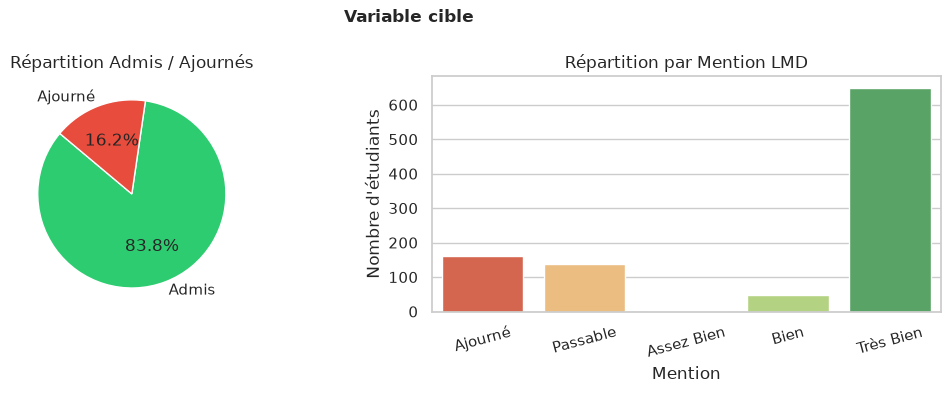

In [6]:
# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['statut_ajourne'].value_counts()
axes[0].pie(counts, labels=['Admis', 'Ajourné'], colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Répartition Admis / Ajournés')

sns.countplot(data=df, x='mention_annuelle', palette='RdYlGn', ax=axes[1], order=labels)
axes[1].set_title('Répartition par Mention LMD')
axes[1].set_xlabel('Mention')
axes[1].set_ylabel("Nombre d'étudiants")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Variable cible', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

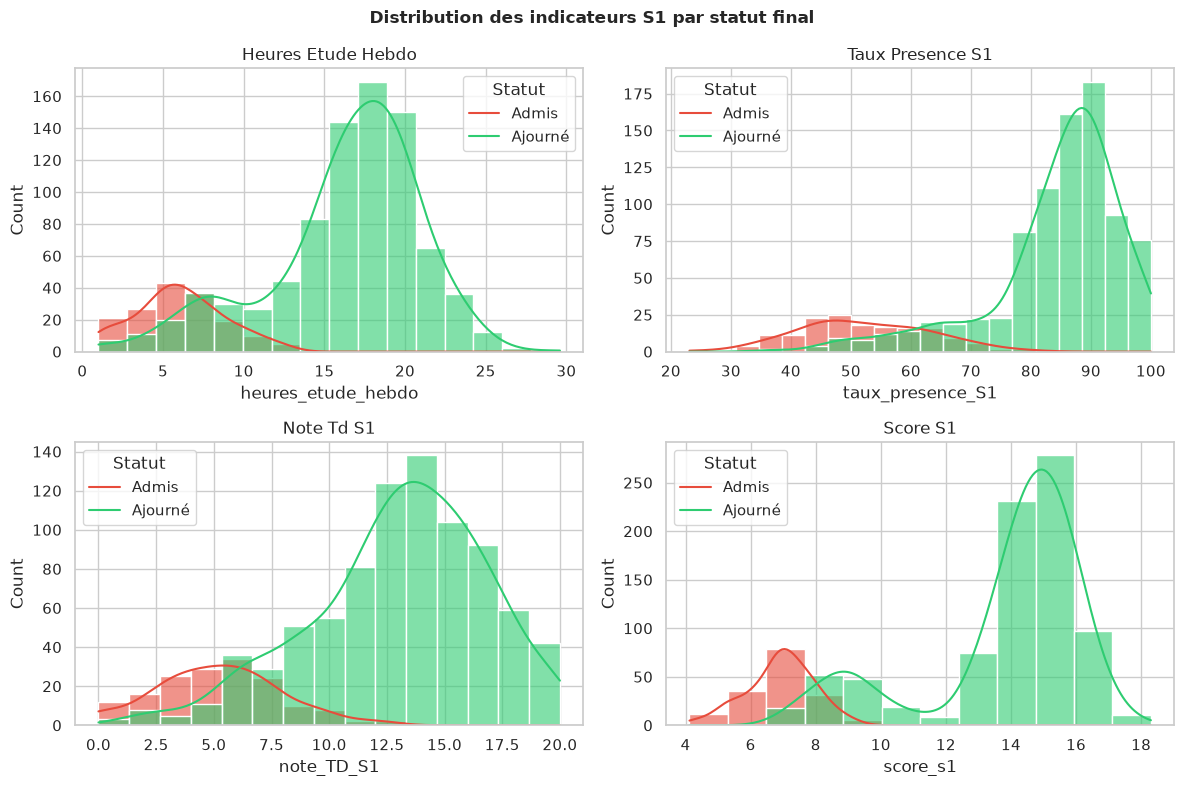

In [7]:
# Distributions des features S1 + score_s1
features_plot = ['heures_etude_hebdo', 'taux_presence_S1', 'note_TD_S1', 'score_s1']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features_plot):
    sns.histplot(data=df, x=feat, hue='statut_ajourne', kde=True, ax=ax,
                 palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(['Admis', 'Ajourné'], title='Statut')

plt.suptitle('Distribution des indicateurs S1 par statut final', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

ValueError: The palette dictionary is missing keys: {'0', '1'}

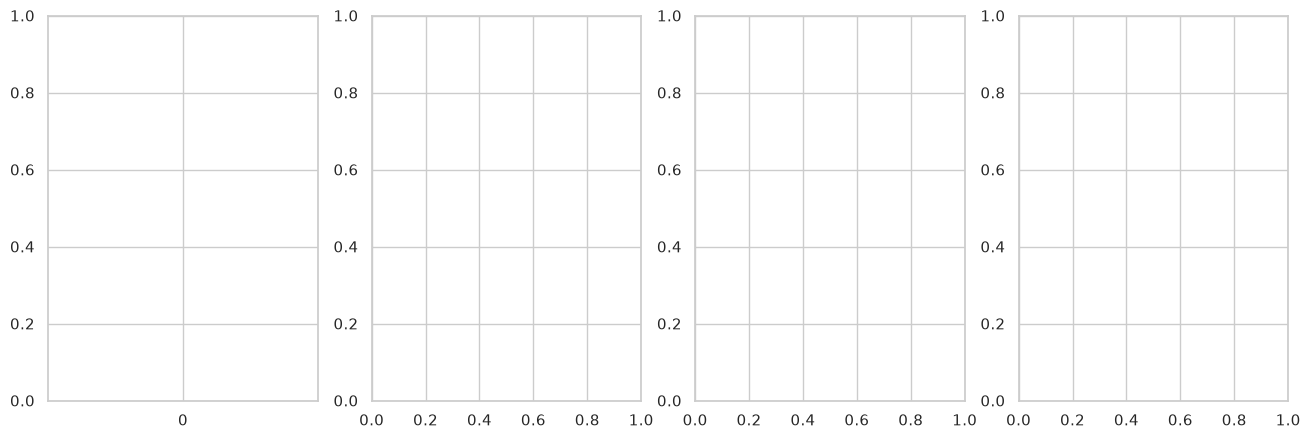

In [8]:
# Boxplots : pouvoir discriminant de chaque feature
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, features_plot):
    sns.boxplot(data=df, x='statut_ajourne', y=feat, ax=ax,
                palette={0: '#2ecc71', 1: '#e74c3c'})
    ax.set_xticklabels(['Admis', 'Ajourné'])
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('')

plt.suptitle('Admis vs Ajournés — Comparaison des indicateurs S1', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

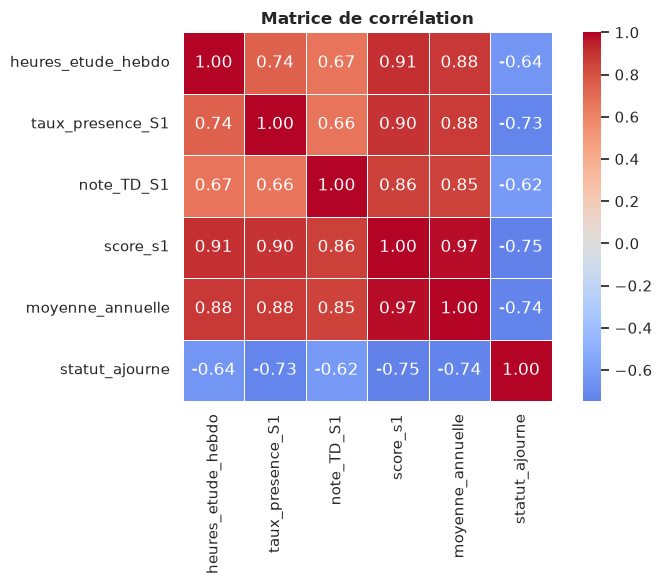

Corrélation des indicateurs S1 avec statut_ajourne :
score_s1             -0.747472
taux_presence_S1     -0.731891
heures_etude_hebdo   -0.644579
note_TD_S1           -0.619930
Name: statut_ajourne, dtype: float64


In [9]:
# Matrice de corrélation
corr_cols = ['heures_etude_hebdo', 'taux_presence_S1', 'note_TD_S1', 'score_s1',
             'moyenne_annuelle', 'statut_ajourne']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Corrélation des indicateurs S1 avec statut_ajourne :")
print(corr['statut_ajourne'][['heures_etude_hebdo','taux_presence_S1','note_TD_S1','score_s1']].sort_values())

## 5. Vérification de l'Équilibre des Classes

In [10]:
balance = df['statut_ajourne'].value_counts(normalize=True)
print("Proportion des classes :")
print(balance.rename({0: 'Admis', 1: 'Ajourné'}))

ratio = balance[1] / balance[0]
if ratio < 0.3:
    print("\n⚠️  Déséquilibre détecté. class_weight='balanced' sera activé dans le notebook 2.")
else:
    print("\n✅  Classes suffisamment équilibrées.")

Proportion des classes :
statut_ajourne
Admis      0.838
Ajourné    0.162
Name: proportion, dtype: float64

⚠️  Déséquilibre détecté. class_weight='balanced' sera activé dans le notebook 2.


## 6. Export du Dataset Propre

In [11]:
cols_export = [
    'student_id',
    'heures_etude_hebdo', 'taux_presence_S1', 'note_TD_S1', 'score_s1',
    'moyenne_annuelle', 'mention_annuelle', 'statut_ajourne'
]

df_clean = df[cols_export].copy()
df_clean.to_csv('dataset_propre.csv', index=False)

print(f"✅ dataset_propre.csv exporté : {df_clean.shape[0]} lignes")
print(f"   Features pour la modélisation : heures_etude_hebdo, taux_presence_S1, note_TD_S1, score_s1")
df_clean.head()

✅ dataset_propre.csv exporté : 1000 lignes
   Features pour la modélisation : heures_etude_hebdo, taux_presence_S1, note_TD_S1, score_s1


,student_id,heures_etude_hebdo,taux_presence_S1,note_TD_S1,score_s1,moyenne_annuelle,mention_annuelle,statut_ajourne
0,1,17.6,81.7,15.6,14.60,19.84,Très Bien,0
1,2,11.9,90.5,14.6,13.70,16.86,Très Bien,0
2,3,8.6,56.8,4.6,7.73,10.40,Passable,0
3,4,6.0,77.1,6.6,9.24,10.40,Passable,0
4,5,18.2,79.9,13.0,13.95,17.50,Très Bien,0
